# Extracellular Stimulation of Axons

In the cable equation with extracellular space, the membrane potential is influenced not only by ionic currents and axial diffusion, but also by an extracellular potential `vext`.  

This extracellular voltage is determined by:  

- External driving potential `e_ext` (e.g. point-source stimulation).  
- Membrane current `i_membrane` (feedback from the neuron).  
- Extracellular conductance `xg` (*mS/cm²*), equivalent to a passive leak.  
- Extracellular capacitance `xc` (*µF/cm²*), equivalent to a capacitive pathway.  

## Formalism (as in NEURON)

- `vext[i]` — Extracellular voltage at segment *i* (mV).  
- `i_membrane` — Total transmembrane current density (mA/cm²).  
- `xg[i]` — Extracellular conductance per area (mho/cm²).  
- `xc[i]` — Extracellular capacitance per area (µF/cm²).  
- `extracellular.e` — Driving extracellular potential (mV).  

The update rule for `vext` is:

$$
C_x \frac{d v_\text{ext}}{dt} + G_x \, v_\text{ext} = G_x \, e_\text{ext} - i_\text{mem}
$$

where:
- $ C_x = xc $  
- $ G_x = xg $  

This equation represents a parallel RC circuit (conductance + capacitance) driven by an external source and loaded by the membrane current.

## Special Cases

- **No capacitance** (`xc = 0`) → purely resistive coupling:  
  $$
  v_\text{ext} = e_\text{ext} - \frac{i_\text{mem}}{xg}
  $$

- **No conductance** (`xg = 0`) → purely capacitive coupling:  
  $$
  \frac{d v_\text{ext}}{dt} = - \frac{i_\text{mem}}{xc}
  $$

- **Short-circuit** (`xg → ∞`, `xc = 0`) → `vext ≈ e_ext`  

## Implementation in the solver

At each simulation time step, the solver performs the following steps:

1. **Compute the extracellular driving potential** `e_ext`  
   - For example, using a point-source approximation.

2. **Compute the ionic current density** `Iion`  
   - Convert to membrane current density in mA/cm² → `i_membrane`.

3. **Update the extracellular potential** `vext`  
   - Using the function `update_vext_single_layer` (or equivalent).

4. **Recompute the membrane voltage** `V_mem`:

$$
V_\text{mem} = V - v_\text{ext}
$$

5. **Use `V_mem` in gating kinetics and current balance**  
   - This updated membrane voltage drives channel dynamics and the total ionic current.

## Python implementation

### 1. Required modules and simulation parameters

In [3]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from axonscope.axons import Axon
from axonscope.simresult import SimResult
import sys

sys.path.append("/Users/louisregnacq/Documents/Work/Model/NRV")   
import nrv
print (nrv.__version__)

#Axon parameters
L = 1000      # um
d = 0.2       # diameter in µm
Nx = 101      # nseg

#PSA parameters
x0 = L/2                        #PSA located at L//2
y0 = 100                        #daxon in um
z0 = 0
sigma = 0.1                       #Conductivity in ???
x_vec = np.linspace(0,L,num=Nx)

#Stimulus parameters
t_start = 1     #ms
t_PW = 1        #ms 
amp = 100       #uA 
t_sim = 10      #ms
dt = 0.001      #ms 


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
1.3.0


### 2. Function for simulating a PSA electrode contribution and stimulus (Equiv. NRV formalism)

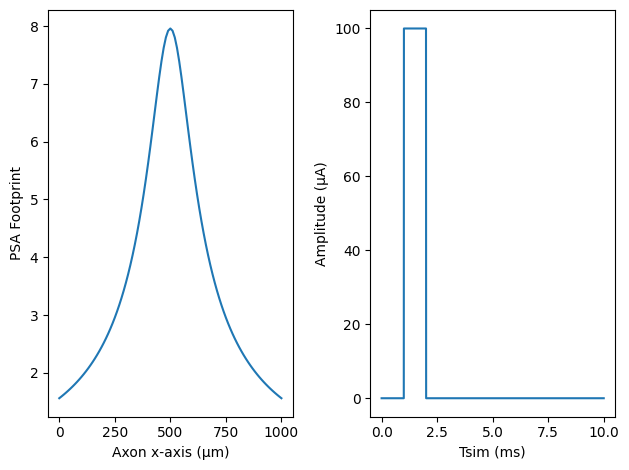

In [134]:
def PSA_ftp(x_vec, x0, y0, z0, sigma):
    r = np.sqrt((x_vec - x0)**2 + y0**2 + z0**2)
    return (1.0 / (4 * np.pi * sigma * r)) * 1e3  # convert to mV


def pulse(t_start,duration,amp,tsim, dt):
    t_vec = np.arange(0, tsim, dt)
    stim = np.zeros_like(t_vec)

    mask = (t_vec >= t_start) & (t_vec < t_start + duration)
    stim[mask] = amp

    return t_vec, stim

psa_ftp = PSA_ftp(x_vec,x0,y0,z0, sigma)
t_vec, I_stim = pulse(t_start,t_PW,amp,t_sim,dt)
fig,axs = plt.subplots(1,2)
axs[0].plot(x_vec,psa_ftp)
axs[1].plot(t_vec, I_stim)

axs[0].set_xlabel("Axon x-axis (µm)")
axs[0].set_ylabel("PSA Footprint")

axs[1].set_xlabel("Tsim (ms)")
axs[1].set_ylabel("Amplitude (µA)")

fig.tight_layout()


### 3. Re-writting of a AxonsScope's RattayAberham axon with extracellular stimulation mechanism

In [135]:
# ----------------------------
# RA axon with extracellular
# ----------------------------
class RattayAberham(Axon):
    """
    Axon model 'RattayAberham' (from hh.mod) with extracellular layer.
    - V in mV
    - Iion(...) returns ionic current density in µA/cm²
    - Gating variables updated by explicit call to step_gates(dt_ms, V)
    """

    def __init__(
        self,
        L,
        d,
        Nx=101,
        Cm=1.0,
        Ra=100.0,
        Vinit=-70.0,
        gnabar=0.12,   # S/cm^2
        gkbar=0.036,   # S/cm^2
        gl=0.0003,     # S/cm^2
        el=-59.4,      # mV
        ena=45.0,      # mV
        ek=-82.0,      # mV
        xg=10.0e9,     # Extracellular layer conductance (mS/cm^2)
        xc=0.0,        # Extracellular layer capacitance (uF/cm^2)
        celsius=37.0,  # degC
    ):
        super().__init__(L=L, d=d, Nx=Nx, Cm=Cm, Ra=Ra, Vinit=Vinit)

        # channel parameters
        self.gnabar = float(gnabar)
        self.gkbar = float(gkbar)
        self.gl = float(gl)
        self.el = float(el)
        self.ena = float(ena)
        self.ek = float(ek)
        self.celsius = float(celsius)
        self.q10 = 2.24659524757**((celsius - 6.3)/10)

        # gating variables
        self.m = np.zeros(self.Nx, dtype=float)
        self.h = np.zeros(self.Nx, dtype=float)
        self.n = np.zeros(self.Nx, dtype=float)

        # extracellular layer
        self.xg = xg                        
        self.xc = xc                        

        # initialize gating variables
        V0 = np.ones(self.Nx) * float(self.Vinit)
        minf, mtau, hinf, htau, ninf, ntau = self._rates(V0)
        self.m[:] = minf
        self.h[:] = hinf
        self.n[:] = ninf

        # x positions (for extracellular potentials)
        self.x_cm = np.linspace(0, L, Nx)

    # ---- HH rates ----
    def alpha_m(self, V_m):
        return (2.5 - 0.1*(V_m+70))/ (np.exp(2.5 - 0.1*(V_m+70)) - 1 + 1e-12)

    def beta_m(self, V_m):
        return 4.0 * np.exp(-(V_m + 70.0)/18.0)

    def alpha_h(self, V_m):
        return 0.07 * np.exp(-(V_m + 70.0)/20.0)

    def beta_h(self, V_m):
        return 1.0 / (np.exp(3.0 - 0.1*(V_m + 70.0)) + 1.0)

    def alpha_n(self, V_m):
        return 0.1 * (1 - 0.1*(V_m+70))/ (np.exp(1 - 0.1*(V_m+70)) - 1 + 1e-12)

    def beta_n(self, V_m):
        return 0.125 * np.exp(-(V_m+70)/80)

    def _rates(self, V_mV):
        v = np.asarray(V_mV, dtype=float)
        # m
        sum_m = np.maximum(self.alpha_m(v) + self.beta_m(v), 1e-12)
        mtau = 1.0 / (self.q10 * sum_m)
        minf = self.alpha_m(v) / sum_m
        # h
        sum_h = np.maximum(self.alpha_h(v) + self.beta_h(v), 1e-12)
        htau = 1.0 / (self.q10 * sum_h)
        hinf = self.alpha_h(v) / sum_h
        # n
        sum_n = np.maximum(self.alpha_n(v) + self.beta_n(v), 1e-12)
        ntau = 1.0 / (self.q10 * sum_n)
        ninf = self.alpha_n(v) / sum_n
        return minf, mtau, hinf, htau, ninf, ntau

    # ---- gating integration ----
    def step_gates(self, dt_ms, V_mV):
        V = np.asarray(V_mV, dtype=float)
        if V.shape != (self.Nx,):
            V = np.full(self.Nx, float(V.item()))
        minf, mtau, hinf, htau, ninf, ntau = self._rates(V)
        mtau = np.maximum(mtau, 1e-12)
        htau = np.maximum(htau, 1e-12)
        ntau = np.maximum(ntau, 1e-12)
        self.m = minf - (minf - self.m)*np.exp(-dt_ms/mtau)
        self.h = hinf - (hinf - self.h)*np.exp(-dt_ms/htau)
        self.n = ninf - (ninf - self.n)*np.exp(-dt_ms/ntau)

    def half_step_gates(self, dt_ms, V_mV) -> None:
        return None

    # ---- ionic currents ----
    def Iion(self, V_mV):
        V_arr = np.asarray(V_mV, dtype=float)
        if V_arr.shape != (self.Nx,):
            V_arr = np.full(self.Nx, float(V_arr.item()))
        gna = self.gnabar*(self.m**3)*self.h
        gk  = self.gkbar*(self.n**4)
        gl  = self.gl
        ina = gna*(V_arr - self.ena)*1e3
        ik  = gk*(V_arr - self.ek)*1e3
        il  = gl*(V_arr - self.el)*1e3
        return ina + ik + il
    

### 4. Definition of the updating function for vext

In [136]:
def update_vext_single_layer(vext, e_ext, i_mem, xg, xc, dt, eps=1e-12):
    """
    Update rule for a single NEURON-style extracellular layer (vectorized). 

    Parameters
    ----------
    vext : array_like
        Current extracellular potential next to the membrane (mV).
    e_ext : array_like
        Driving potential of the layer (mV).
    i_mem : array_like
        Membrane current density (mA/cm^2). Positive = outward.
    xg : array_like
        Extracellular conductance (mho/cm^2).
    xc : array_like
        Extracellular capacitance (uF/cm^2).
    dt : float
        Timestep (ms).
    eps : float
        Small threshold for zero tests.

    Returns
    -------
    vext_new : np.ndarray
        Updated extracellular potential (mV).
    """
    vext   = np.asarray(vext, dtype=float)
    e_ext  = np.asarray(e_ext, dtype=float)
    i_mem  = np.asarray(i_mem, dtype=float)
    xg     = np.asarray(xg, dtype=float)
    xc     = np.asarray(xc, dtype=float)

    vnew = vext.copy()

    # Masks
    cap_pos  = xc > eps
    g_pos    = xg > eps
    cap_zero = ~cap_pos
    g_zero   = ~g_pos

    # Case A: xc > 0 and xg > 0 (exact exponential solution)
    mask_A = cap_pos & g_pos
    if np.any(mask_A):
        alpha = (xg[mask_A] / xc[mask_A]) * dt  # dimensionless
        expa  = np.exp(-alpha)
        vss   = e_ext[mask_A] - i_mem[mask_A] / xg[mask_A]  # steady state
        vnew[mask_A] = vext[mask_A] * expa + vss * (1.0 - expa)

    # Case B: xc > 0 and xg == 0 (dv/dt = -i_mem/xc)
    mask_B = cap_pos & g_zero
    if np.any(mask_B):
        vnew[mask_B] = vext[mask_B] - (i_mem[mask_B] / xc[mask_B]) * dt

    # Case C: xc == 0 and xg > 0 (algebraic constraint)
    mask_C = cap_zero & g_pos
    if np.any(mask_C):
        vnew[mask_C] = e_ext[mask_C] - i_mem[mask_C] / xg[mask_C]

    # Case D: xc == 0 and xg == 0 (floating; no coupling) -> keep previous vext
    # mask_D = cap_zero & g_zero  # implicitly handled by copy

    return vnew

### 5. Re-writting of a AxonsScope's Euler solver with extracellular stimulation mechanism

In [137]:
class EulerExtracellular:
    def __init__(self):
        pass

    def solve(self, axon: RattayAberham, tsim, dt, PSA_ftp, I_stim) -> SimResult:       #we add extracellular stim here (for this example only!!)
        Nt = int(np.ceil(tsim/dt))
        V = np.ones(axon.Nx)*axon.Vinit
        V_all = np.zeros((Nt, axon.Nx))
        t_vec = np.zeros(Nt)
        vext = np.zeros(axon.Nx)       # mV
        t = 0.0

        for n in range(Nt):
            t_vec[n] = t

            e_ext = PSA_ftp*I_stim[n]       #Compute the extracellular stimulation 

            # Courant de membrane (µA/cm² → mA/cm²)
            V_mem = V - e_ext
            axon.step_gates(dt, V_mem)
            Iion = axon.Iion(V_mem)
            i_mem = Iion * 1e-3   # conversion en mA/cm²

            # We update vext
            vext = update_vext_single_layer(
                vext=vext,
                e_ext=e_ext,
                i_mem=i_mem,
                xg=axon.xg,
                xc=axon.xc,
                dt=dt
            )

            # We redifine V_mem with updated vex
            V_mem = V - vext

            # Axial diffusion
            d2vdx2 = np.zeros_like(V)
            d2vdx2[1:-1] = (V[2:] - 2*V[1:-1] + V[:-2]) / axon.dx_cm**2
            Idiff = axon.D * d2vdx2 * axon.Cm

            # Cable equation
            dVdt = (Idiff - Iion + axon.Iinj_uAcm2(t)) / axon.Cm
            V_new = V + dt*dVdt

            # Boundary conditions
            V_new[0] = axon.Vinit
            V_new[-1] = axon.Vinit

            V_all[n, :] = V_new
            V = V_new
            t += dt


        return SimResult(axon, V_all, t_vec)


### 6. Test and comparison with NRV

In [138]:
axon = RattayAberham(L=L, d=d, Nx=Nx, celsius=37)

# --- solver setup
solver = EulerExtracellular()
result = solver.solve(axon, tsim=t_sim, dt=dt, PSA_ftp=psa_ftp, I_stim=I_stim)

center_idx = axon.Nx // 2
V_center = result.Vm[:, center_idx]
model="Rattay_Aberham"


y = 0                        # axon y position, in [um]
z = 0                        # axon z position, in [um]
axon1 = nrv.unmyelinated(y,z,d,L,model = model)

E1 = nrv.point_source_electrode(x0,y0,z0)

# load material properties
epineurium = nrv.load_material('endoneurium_bhadra')

# stimulus def

stim1 = nrv.stimulus()
stim1.pulse(t_start, amp, t_PW)

extra_stim = nrv.stimulation(epineurium)
extra_stim.add_electrode(E1, stim1)
axon1.attach_extracellular_stimulation(extra_stim)
results = axon1.simulate(t_sim=5)
del axon1


plt.figure()
map = plt.pcolormesh(results['t'], results['x_rec'], results['V_mem'] ,shading='auto')
plt.xlabel('time (ms)')
plt.ylabel('position (µm)')
cbar = plt.colorbar(map)
cbar.set_label('membrane voltage (mV)')


    # plt.show()

fig, axs = plt.subplots(1,2,figsize=(8,4))
axs[0].plot(result.t, V_center, label='V_mem (center)')
axs[0].set_xlabel("Time (ms)")
axs[0].set_ylabel("Vm (mV)")

# --- Plot 2: 2D space–time voltage map
extent = [0, t_sim, 0, L]  # [time(ms), position(cm)]
map = axs[1].imshow(
    result.Vm.T,
    aspect="auto",
    extent=extent,
    origin="lower",
    cmap="viridis"
)

axs[1].set_xlabel("Time (ms)")
axs[1].set_ylabel("Position along axon (µm)")
cbar = fig.colorbar(map)
cbar.set_label('membrane voltage - AxonScope (mV)')

fig.tight_layout()


AttributeError: module 'nrv' has no attribute 'unmyelinated'